In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

def make_combination(config_dict):
    keys, values = zip(*config_dict.items())
    return [dict(zip(keys, v)) for v in itertools.product(*values)]

In [2]:
UEA_MTSC30 = ['EthanolConcentration',
              'FaceDetection',
              'Handwriting',
              'Heartbeat',
              'JapaneseVowels',
              'PEMS-SF',
              'SelfRegulationSCP1',
              'SelfRegulationSCP2',
              'SpokenArabicDigits',
              'UWaveGestureLibrary',
              'ArticularyWordRecognition',
              'AtrialFibrillation',
              'BasicMotions',
              'CharacterTrajectories',
              'Cricket',
              'DuckDuckGeese',
              'EigenWorms',
              'Epilepsy',
              'ERing',
              'FingerMovements',
              'HandMovementDirection',
              'InsectWingbeat',
              'Libras',
              'LSST',
              'MotorImagery',
              'NATOPS',
              'PenDigits',
              'PhonemeSpectra',
              'RacketSports',
              'StandWalkJump']

In [3]:
from omegaconf import OmegaConf
data_info = OmegaConf.load(f"../data_classification.yaml")

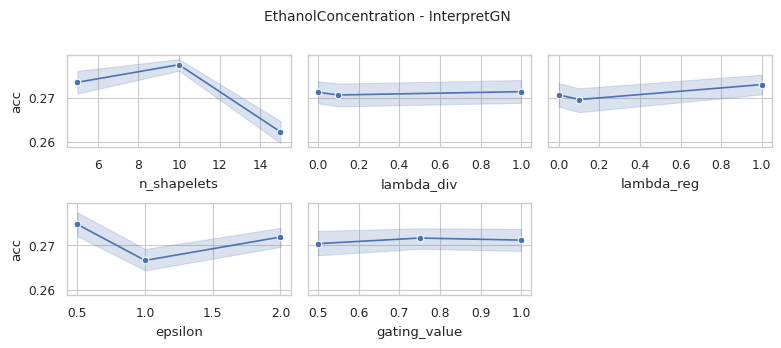

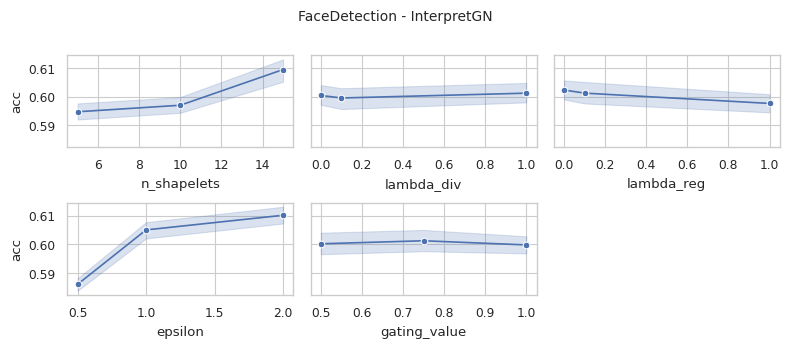

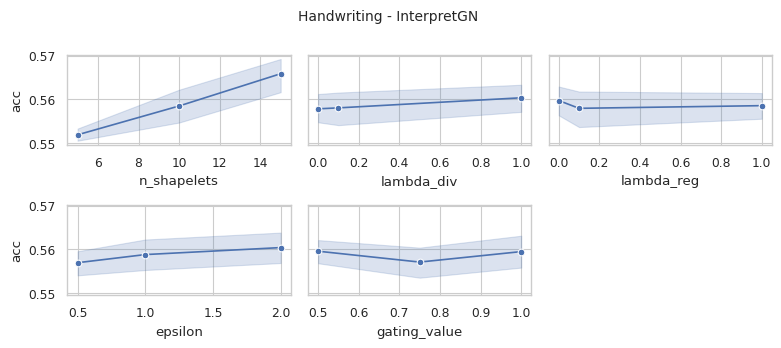

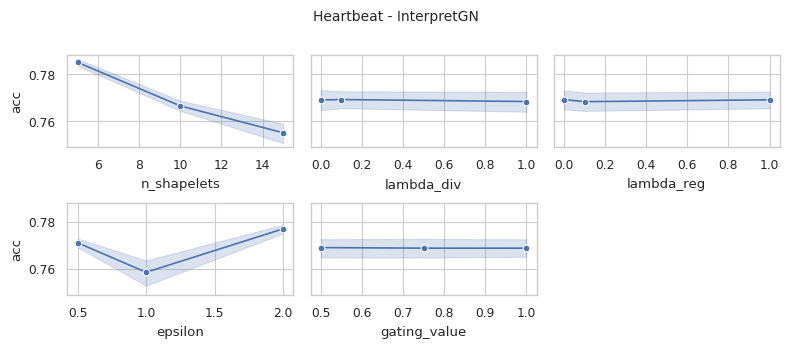

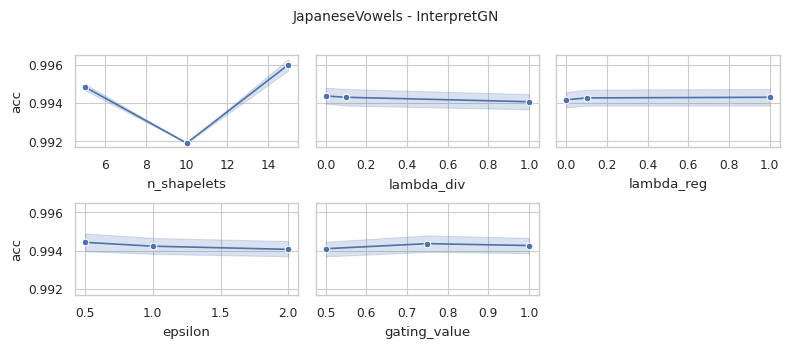

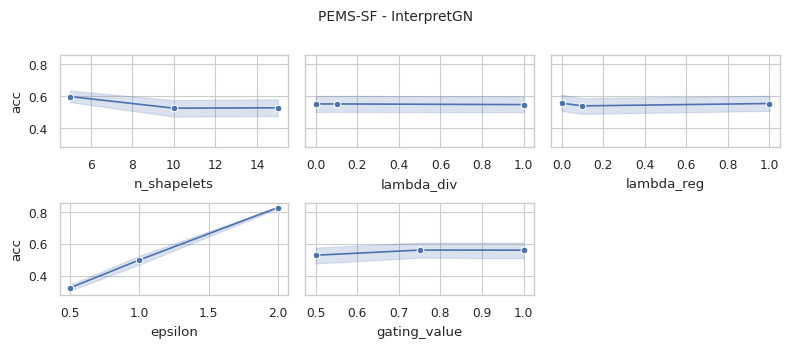

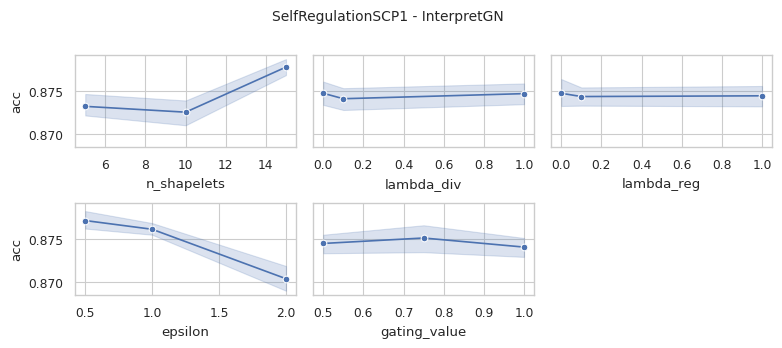

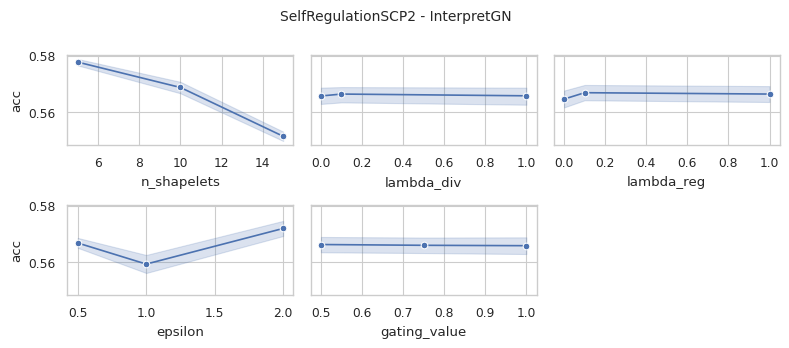

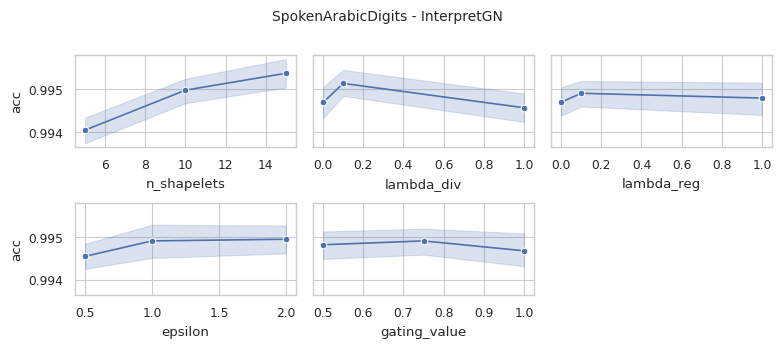

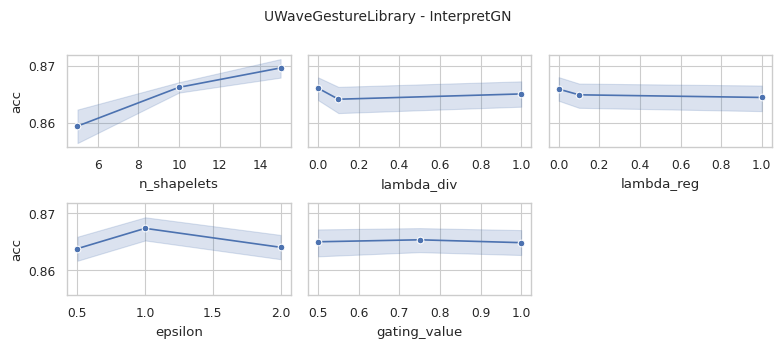

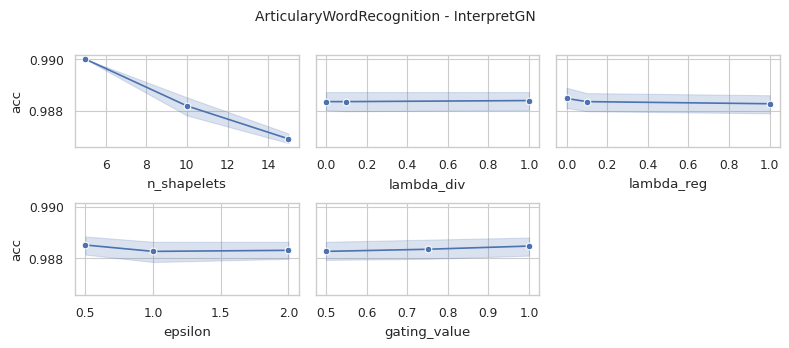

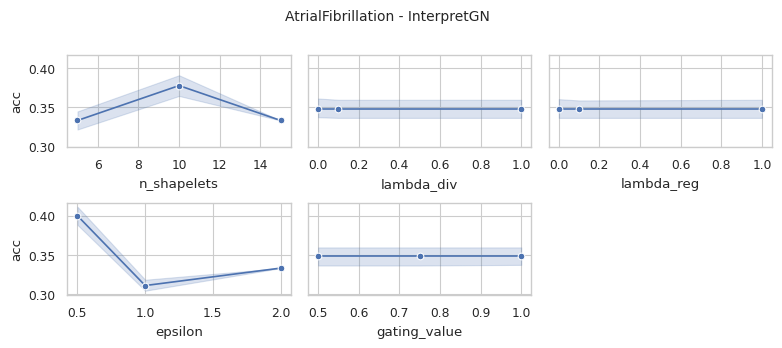

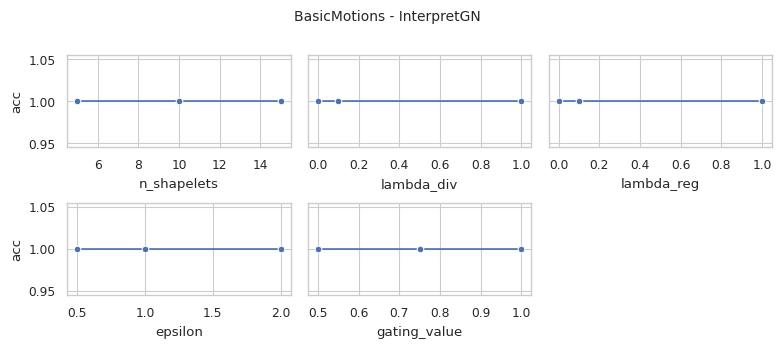

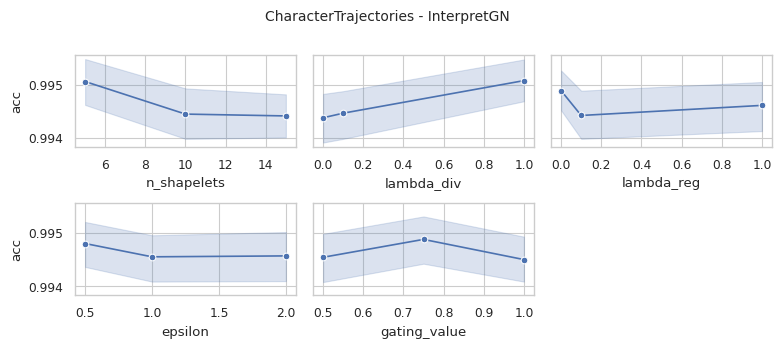

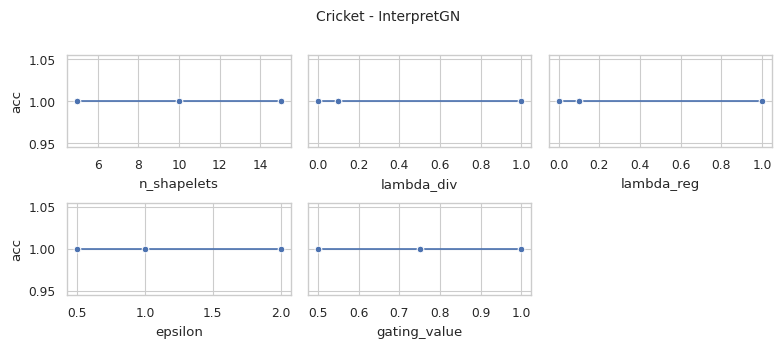

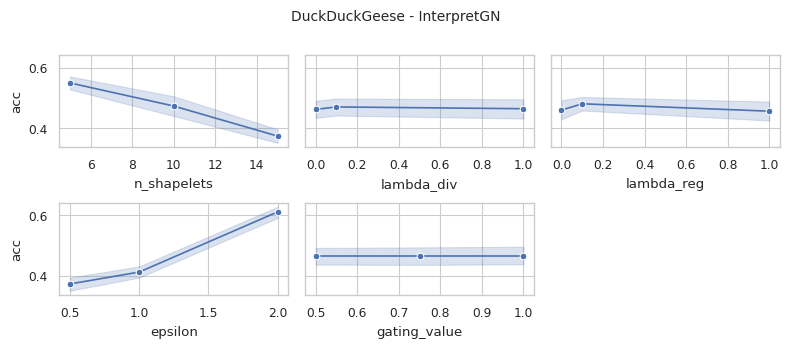

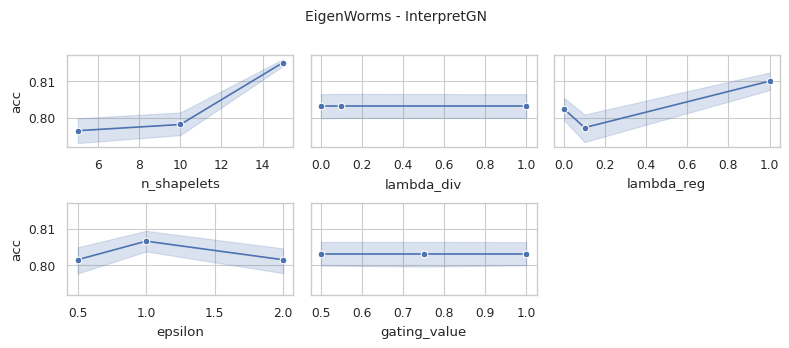

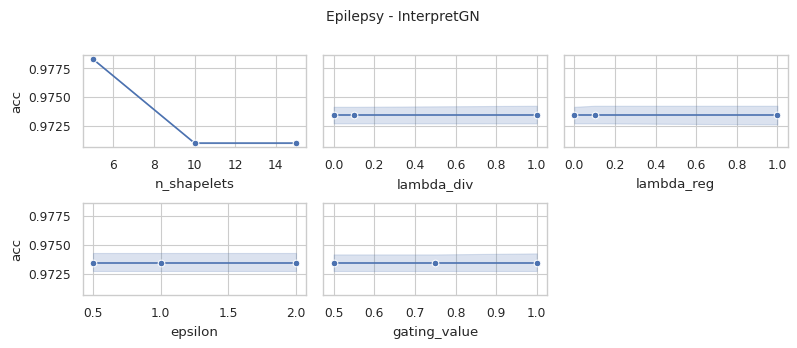

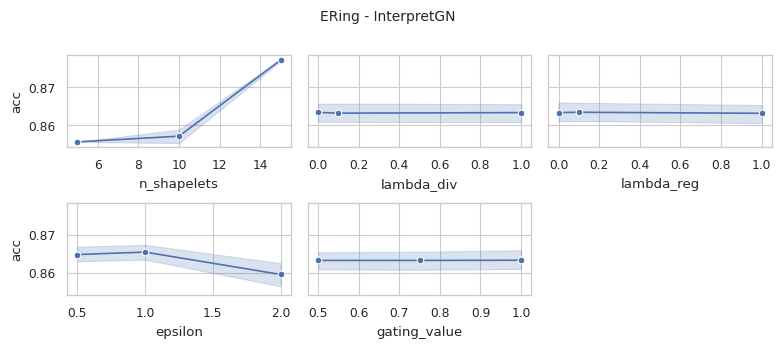

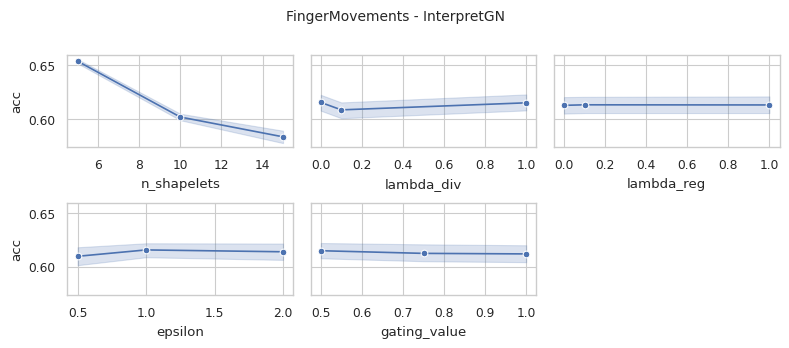

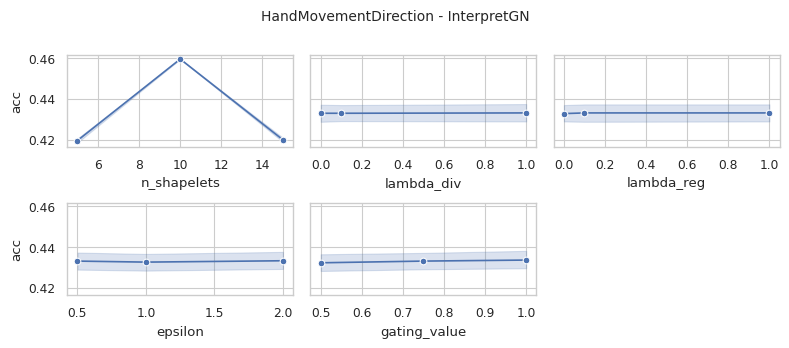

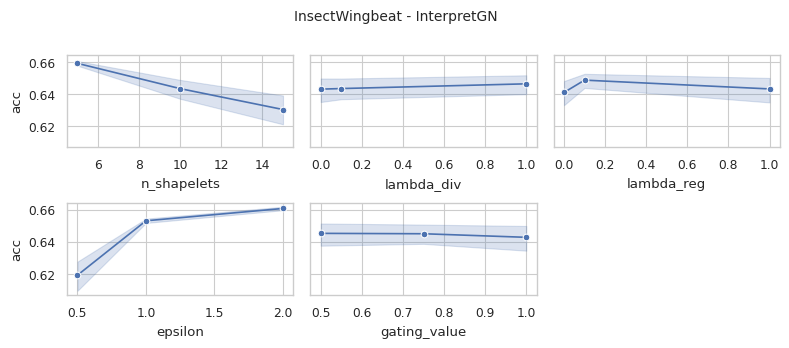

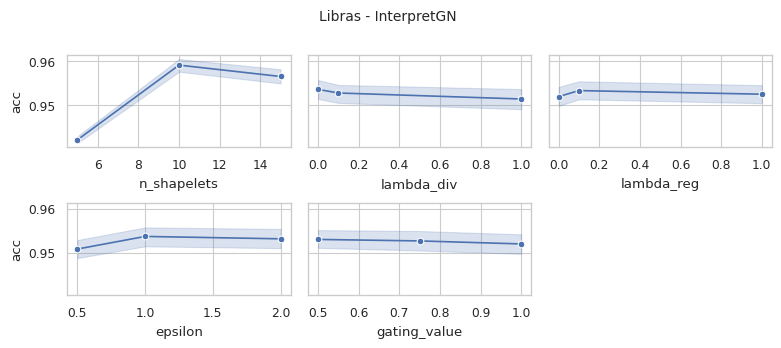

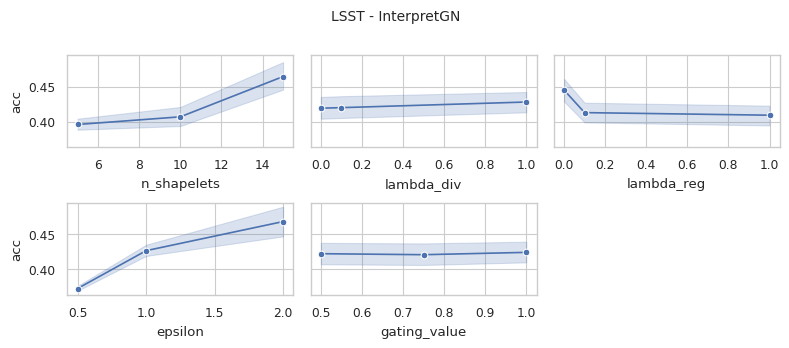

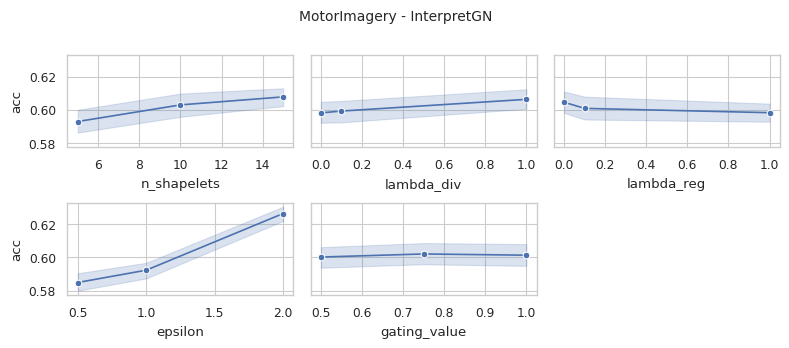

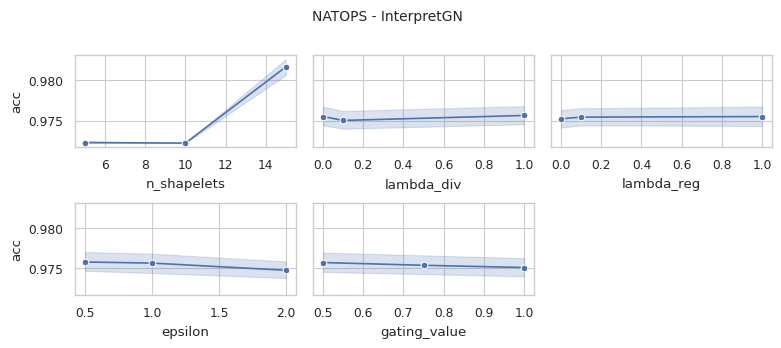

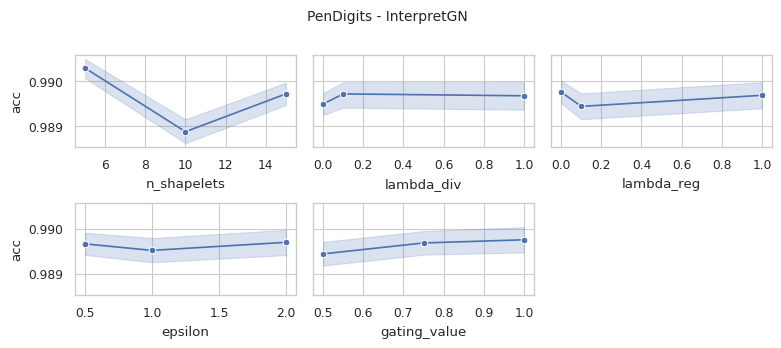

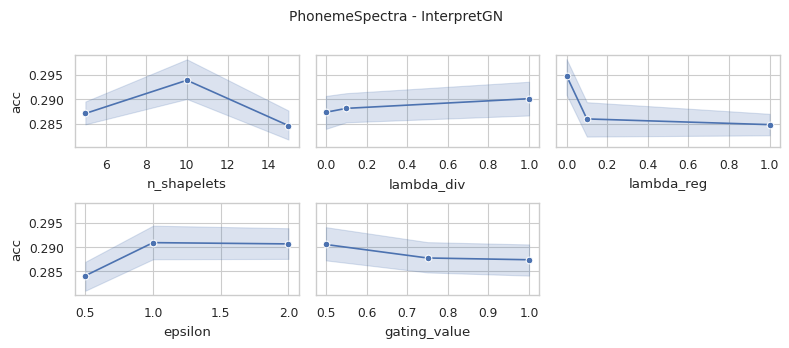

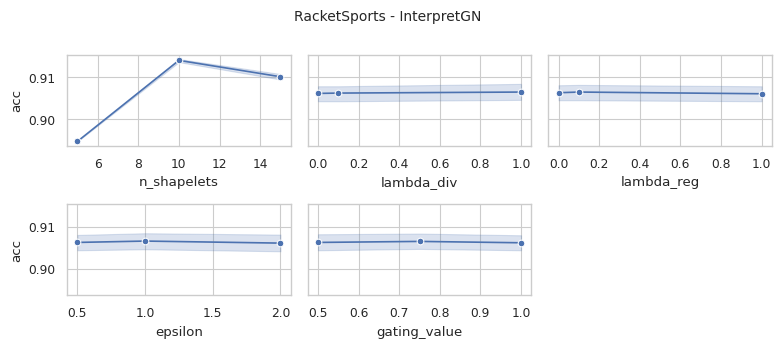

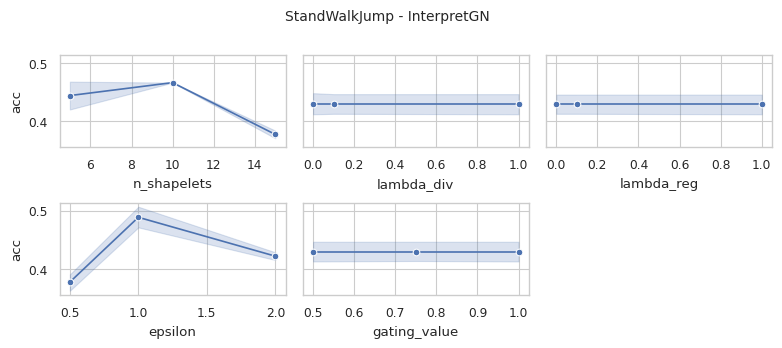

In [4]:
model = 'InterpretGN'
result_dict = dict()

for data_name in UEA_MTSC30:
    
    if os.path.exists(f'../03-full_results/{model}/{model}_CLS_{data_name}.out'):
        with open(f'../03-full_results/{model}/{model}_CLS_{data_name}.out', 'r') as file:
            data = file.read().splitlines()
    else:
        print('no file')
        continue


    result_lst = list()
    for i in range(len(data)):
        if data[i].startswith('>>>>>>>testing : '):
            # dnnFCN_ns15_div1.0_reg1.0_eps2.0_dfunceuclidean_memFalse_clslinear_gate1.0_Exp_0
            data_meta = list(data[i][16:-33].split('_'))
            data_meta[6] = int(data_meta[6].replace('sl', ''))
            data_meta[7] = int(data_meta[7].replace('ll', ''))
            data_meta[8] = int(data_meta[8].replace('pl', ''))
            data_meta[9] = data_meta[9].replace('dnn', '')
            data_meta[10] = int(data_meta[10].replace('ns', ''))
            data_meta[11] = float(data_meta[11].replace('div', ''))
            data_meta[12] = float(data_meta[12].replace('reg', ''))
            data_meta[13] = float(data_meta[13].replace('eps', ''))
            data_meta[14] = data_meta[14].replace('dfunc', '')
            data_meta[15] = True if data_meta[15].replace('mem', '') == 'True' else False
            data_meta[16] = data_meta[16].replace('cls', '')
            data_meta[17] = float(data_meta[17].replace('gate', ''))


            acc = data[i+3].replace('accuracy:', '')
            model_params = data[i+4].replace('model parameter : ', '')
            model_size = data[i+5].replace('model size : ', '').replace('MB', '')
            result_data = {
                # 'task': data_meta[0],
                # 'model_id': data_meta[1],
                'data_name': data_meta[2],
                'model': data_meta[3],
                # 'data': data_meta[4],
                # 'feature': data_meta[5],
                'seq_len': data_meta[6],
                # 'label_len': data_meta[7],
                # 'pred_len': data_meta[8],
                'dnn_type': data_meta[9],
                'n_shapelets': data_meta[10],
                'lambda_div': data_meta[11],
                'lambda_reg': data_meta[12],
                'epsilon': data_meta[13],
                'distance': data_meta[14],
                'memory_efficient': data_meta[15],
                'sbm_classifier': data_meta[16],
                'gating_value': data_meta[17],
                'acc': float(acc),
                'model_params': int(model_params),
                'model_size (MB)': float(model_size)
            }

            result_lst.append(result_data)

    result_df = pd.DataFrame(result_lst)
    os.makedirs(f'./{model}', exist_ok=True)
    result_df.to_csv(f'./{model}/{data_name}.csv', index=False)
    result_dict[data_name] = result_df.copy()

    cols = ['n_shapelets', 'lambda_div', 'lambda_reg', 'epsilon', 'gating_value']
    num_cols, num_rows = 3, 2
    
    # # Boxplot
    # sns.set_theme(style="whitegrid")
    # sns.set_context("paper", font_scale=1)
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)

    # Lineplot
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1)
    fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    for i, col in enumerate(cols):
        if result_df[col].unique().size == 1: 
            sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False)
        else:
            sns.lineplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False, style='model', markers=True)
    for i in range(len(cols), num_cols*num_rows):
        fig.delaxes(axs[i//num_cols][i%num_cols])
    fig.suptitle(f'{data_name} - {model}', fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    display(fig)
    plt.savefig(f'./{model}/{data_name}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    

    # # Lineplot where each line represents same hyperparameter combination except one
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     col_rest = [c for c in cols if c != col]
    #     tmp_result = result_df.pivot_table(index=col_rest, columns=col, values='acc')
    #     tmp_result = pd.DataFrame(tmp_result.values, columns=tmp_result.columns)
    #     max_idx = tmp_result.mean(axis=1).idxmax()
    #     axs[i//num_cols][i%num_cols].plot(tmp_result.T, marker='.', color='#111', alpha=0.2)
    #     axs[i//num_cols][i%num_cols].plot(tmp_result.iloc[max_idx].T, marker='o', color='red', alpha=0.5)
    #     axs[i//num_cols][i%num_cols].grid(False)
    #     axs[i//num_cols][i%num_cols].set_xlabel(col)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)
    

In [5]:
model_configs = {
    "dnn_type" : ["FCN"],
    "num_shapelet" : [5, 10, 15],
    "lambda_div" : [0, 0.1, 1],
    "lambda_reg" : [0, 0.1, 1],
    "epsilon" : [0.5, 1, 2],
    "gating_value" : [0.5, 0.75, 1.0],
}

hyperparameter_combinations = make_combination(model_configs)

acc_all_df = pd.DataFrame(index=UEA_MTSC30, 
                          columns=[str(hp_comb) for hp_comb in hyperparameter_combinations])
for data_name in UEA_MTSC30:
    acc_data_dict = dict()
    for hyperparameter_combination in hyperparameter_combinations:
        dnn_type = hyperparameter_combination['dnn_type']
        n_shapelets = hyperparameter_combination['num_shapelet']
        lambda_div = hyperparameter_combination['lambda_div']
        lambda_reg = hyperparameter_combination['lambda_reg']
        epsilon = hyperparameter_combination['epsilon']
        gating_value = hyperparameter_combination['gating_value']

        if result_dict.get(data_name) is None:
            continue

        tmp = result_dict[data_name]
        try:
            acc = tmp[
                (tmp['dnn_type'] == dnn_type)
                & (tmp['n_shapelets'] == n_shapelets)
                & (tmp['lambda_div'] == lambda_div)
                & (tmp['lambda_reg'] == lambda_reg)
                & (tmp['epsilon'] == epsilon)
                & (tmp['gating_value'] == gating_value)
            ]['acc'].values[0]
        except:
            acc = None
            print(f'no acc for {data_name} with {hyperparameter_combination}')
        acc_data_dict[str(hyperparameter_combination)] = acc

    acc_all_df.loc[data_name] = pd.Series(acc_data_dict)



In [6]:
acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)
acc_all_df.loc['avg'] = acc_all_df.mean(axis=0)
acc_all_df.sort_values(by='avg', ascending=False, inplace=True, axis=1)
acc_all_df

,max,"{'dnn_type': 'FCN', 'num_shapelet': 10, 'lambda_div': 1, 'lambda_reg': 0, 'epsilon': 2, 'gating_value': 1.0}","{'dnn_type': 'FCN', 'num_shapelet': 10, 'lambda_div': 1, 'lambda_reg': 0, 'epsilon': 2, 'gating_value': 0.75}","{'dnn_type': 'FCN', 'num_shapelet': 10, 'lambda_div': 1, 'lambda_reg': 0, 'epsilon': 2, 'gating_value': 0.5}","{'dnn_type': 'FCN', 'num_shapelet': 10, 'lambda_div': 0, 'lambda_reg': 0, 'epsilon': 2, 'gating_value': 1.0}","{'dnn_type': 'FCN', 'num_shapelet': 10, 'lambda_div': 0.1, 'lambda_reg': 0, 'epsilon': 2, 'gating_value': 0.5}","{'dnn_type': 'FCN', 'num_shapelet': 10, 'lambda_div': 0, 'lambda_reg': 0, 'epsilon': 2, 'gating_value': 0.75}","{'dnn_type': 'FCN', 'num_shapelet': 10, 'lambda_div': 0.1, 'lambda_reg': 0, 'epsilon': 2, 'gating_value': 0.75}","{'dnn_type': 'FCN', 'num_shapelet': 10, 'lambda_div': 0, 'lambda_reg': 0, 'epsilon': 2, 'gating_value': 0.5}","{'dnn_type': 'FCN', 'num_shapelet': 10, 'lambda_div': 0.1, 'lambda_reg': 0, 'epsilon': 2, 'gating_value': 1.0}",...,"{'dnn_type': 'FCN', 'num_shapelet': 15, 'lambda_div': 0.1, 'lambda_reg': 1, 'epsilon': 0.5, 'gating_value': 0.75}","{'dnn_type': 'FCN', 'num_shapelet': 15, 'lambda_div': 0.1, 'lambda_reg': 0, 'epsilon': 0.5, 'gating_value': 1.0}","{'dnn_type': 'FCN', 'num_shapelet': 15, 'lambda_div': 1, 'lambda_reg': 1, 'epsilon': 0.5, 'gating_value': 0.75}","{'dnn_type': 'FCN', 'num_shapelet': 15, 'lambda_div': 0, 'lambda_reg': 1, 'epsilon': 0.5, 'gating_value': 1.0}","{'dnn_type': 'FCN', 'num_shapelet': 15, 'lambda_div': 0, 'lambda_reg': 0, 'epsilon': 0.5, 'gating_value': 0.5}","{'dnn_type': 'FCN', 'num_shapelet': 15, 'lambda_div': 1, 'lambda_reg': 0, 'epsilon': 0.5, 'gating_value': 0.75}","{'dnn_type': 'FCN', 'num_shapelet': 15, 'lambda_div': 0.1, 'lambda_reg': 1, 'epsilon': 0.5, 'gating_value': 0.5}","{'dnn_type': 'FCN', 'num_shapelet': 15, 'lambda_div': 0, 'lambda_reg': 0, 'epsilon': 0.5, 'gating_value': 1.0}","{'dnn_type': 'FCN', 'num_shapelet': 15, 'lambda_div': 0, 'lambda_reg': 0, 'epsilon': 0.5, 'gating_value': 0.75}","{'dnn_type': 'FCN', 'num_shapelet': 15, 'lambda_div': 1, 'lambda_reg': 0, 'epsilon': 0.5, 'gating_value': 1.0}"
EthanolConcentration,0.288973,0.285171,0.285171,0.281369,0.285171,0.285171,0.285171,0.285171,0.285171,0.285171,...,0.254753,0.281369,0.281369,0.262357,0.262357,0.269962,0.269962,0.277567,0.26616,0.258555
FaceDetection,0.637911,0.60017,0.608116,0.59336,0.614642,0.612089,0.617196,0.613507,0.603008,0.6084,...,0.60017,0.588252,0.598751,0.599319,0.599035,0.599886,0.595914,0.594211,0.585414,0.575482
Handwriting,0.587059,0.570588,0.570588,0.562353,0.564706,0.571765,0.534118,0.567059,0.578824,0.537647,...,0.564706,0.565882,0.569412,0.563529,0.563529,0.561176,0.563529,0.563529,0.576471,0.565882
Heartbeat,0.804878,0.780488,0.780488,0.780488,0.780488,0.780488,0.780488,0.780488,0.780488,0.780488,...,0.770732,0.770732,0.770732,0.770732,0.770732,0.770732,0.770732,0.770732,0.770732,0.770732
JapaneseVowels,0.997297,0.991892,0.991892,0.991892,0.991892,0.991892,0.991892,0.991892,0.991892,0.991892,...,0.994595,0.997297,0.997297,0.997297,0.994595,0.994595,0.997297,0.997297,0.997297,0.997297
PEMS-SF,0.861272,0.83237,0.82659,0.843931,0.83815,0.849711,0.83237,0.843931,0.83815,0.843931,...,0.265896,0.17341,0.156069,0.317919,0.248555,0.289017,0.17341,0.283237,0.219653,0.17341
SelfRegulationSCP1,0.904437,0.863481,0.863481,0.863481,0.863481,0.863481,0.863481,0.863481,0.863481,0.863481,...,0.887372,0.880546,0.877133,0.877133,0.877133,0.880546,0.880546,0.880546,0.880546,0.880546
SelfRegulationSCP2,0.583333,0.572222,0.572222,0.572222,0.572222,0.572222,0.577778,0.572222,0.572222,0.572222,...,0.555556,0.555556,0.555556,0.555556,0.555556,0.555556,0.555556,0.555556,0.555556,0.555556
SpokenArabicDigits,0.998636,0.992724,0.994998,0.993633,0.996362,0.994543,0.995907,0.996362,0.994543,0.997271,...,0.994998,0.994088,0.996362,0.991814,0.996362,0.995907,0.994543,0.996817,0.99136,0.994543
UWaveGestureLibrary,0.884375,0.865625,0.86875,0.865625,0.86875,0.

In [7]:
pd.set_option("display.precision", 14)
acc_all_df.iloc[:,[0,1]]*100

,max,"{'dnn_type': 'FCN', 'num_shapelet': 10, 'lambda_div': 1, 'lambda_reg': 0, 'epsilon': 2, 'gating_value': 1.0}"
EthanolConcentration,28.89733840304182,28.51711026615969
FaceDetection,63.7911464245176,60.01702610669694
Handwriting,58.70588235294117,57.05882352941176
Heartbeat,80.48780487804879,78.04878048780488
JapaneseVowels,99.72972972972973,99.18918918918919
PEMS-SF,86.1271676300578,83.23699421965318
SelfRegulationSCP1,90.44368600682594,86.3481228668942
SelfRegulationSCP2,58.33333333333334,57.22222222222222
SpokenArabicDigits,99.86357435197817,99.27239654388357
UWaveGestureLibrary,88.4375,86.5625
